In [106]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ruchikakumbhar/calories-burnt-prediction/calories.csv


# Understand Data

In [107]:
df = pd.read_csv('/kaggle/input/datasets/ruchikakumbhar/calories-burnt-prediction/calories.csv')

df.head() # Inspect first rows

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [108]:
df.info() # Check null values and dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [109]:
df.describe() # Briefly inspect if biological measures make sense

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [110]:
df.duplicated().sum() # check for duplicate rows

np.int64(0)

In [111]:
df.drop("User_ID", axis=1, inplace=True) # Drop unrelated column
df.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,female,27,154.0,58.0,10.0,81.0,39.8,35.0


# Exploratory Data Analysis

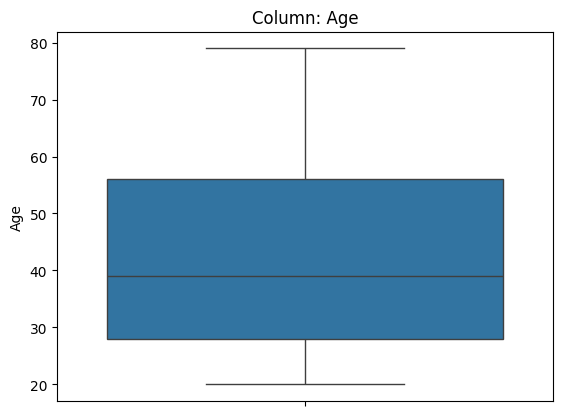

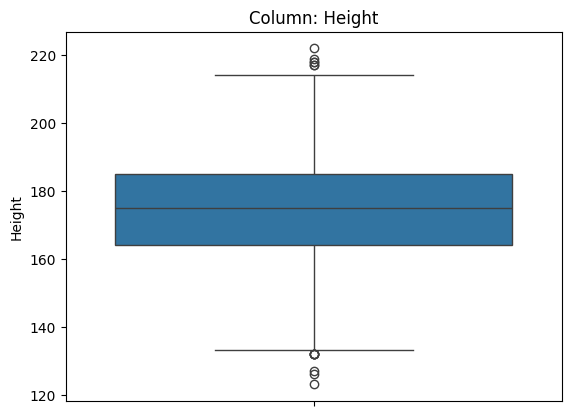

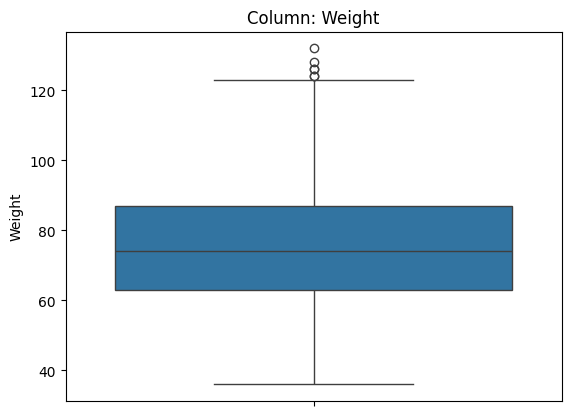

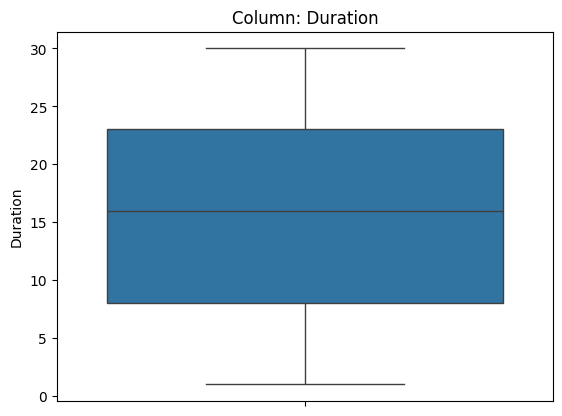

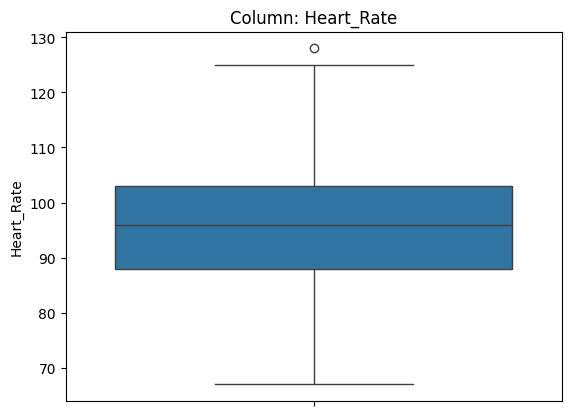

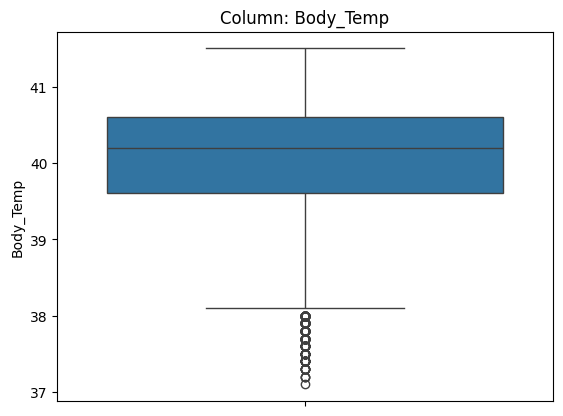

In [112]:
def visualize_outliers(data, target_c): # This function that takes two parameters: data (a DataFrame) and target_c (the target/dependent column to drop from the visualization).
    data = data.drop(target_c, axis=1) # This line drops the specified target column (target_c) from the DataFrame (data). This is done to avoid visualizing the boxplot for the target column itself.
    for c in data.columns: # Inside the loop, it checks if the data type of the column is either 'int' or 'float'. If it is, a boxplot is created using sns.boxplot(data[c]).
        if (data[c].dtype == 'int') or (data[c].dtype == 'float'):
            sns.boxplot(data[c]);
            plt.title(f'Column: {c}')
            plt.show()
            
visualize_outliers(data=df, target_c='Calories')

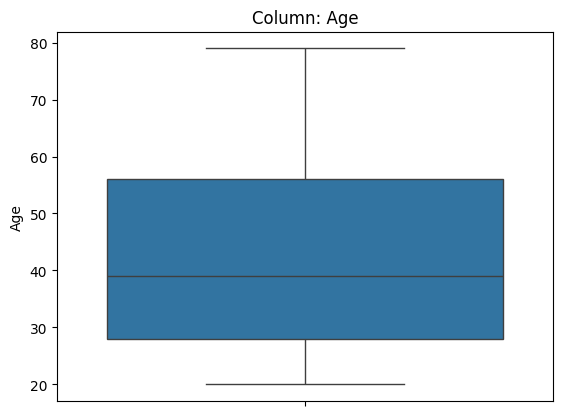

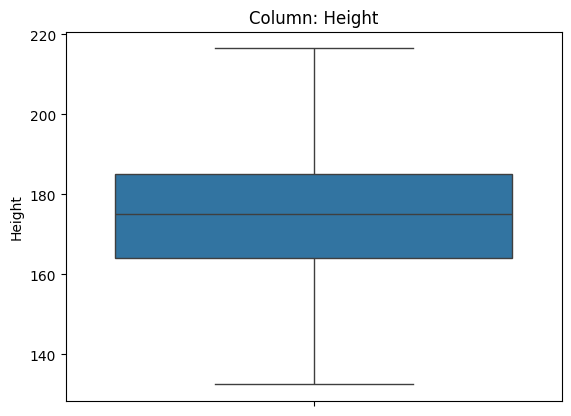

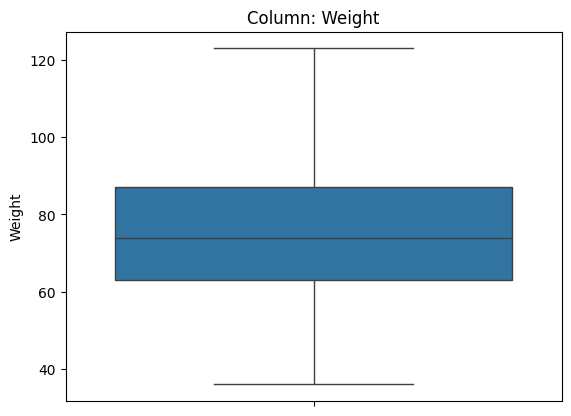

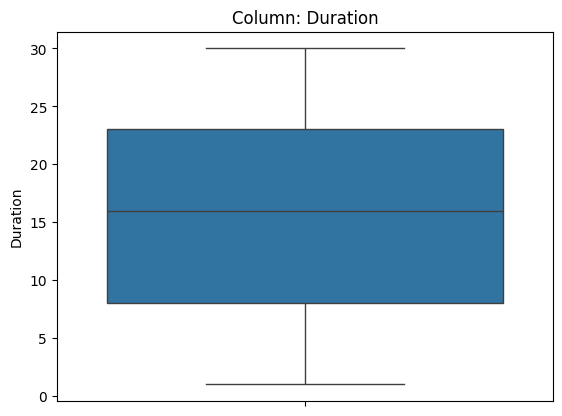

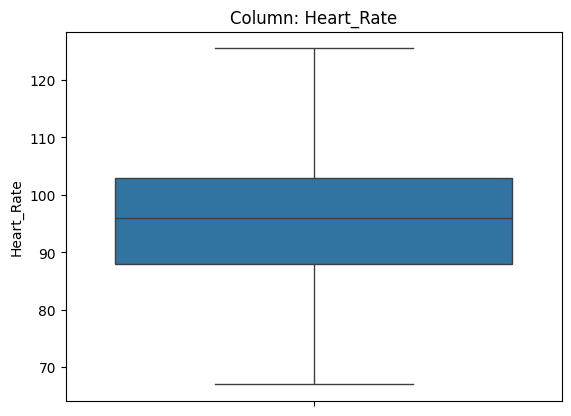

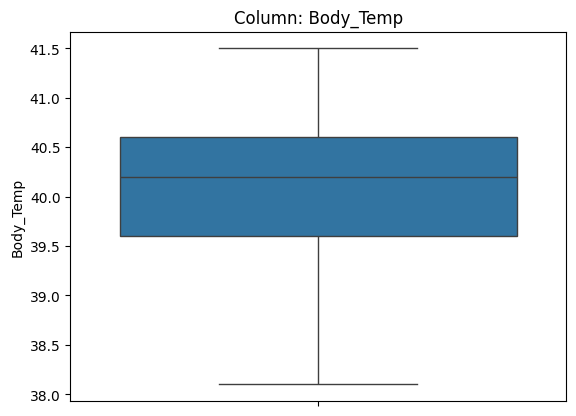

In [113]:
# Handling outliers.
def handling_outliers(data, target_c, q1_p=0.25, q3_p=0.75):
    """
    Handle outliers in a DataFrame using the IQR method.

    Parameters:
    - data: DataFrame
    - target_c: str
        The target column to exclude from outlier handling.
    - q1_p: float, optional (default=0.25)
        The percentile for the first quartile (Q1).
    - q3_p: float, optional (default=0.75)
        The percentile for the third quartile (Q3).
    """
    for c in data.columns:
        # Check if the column is numeric and not the target column
        if ((data[c].dtype == 'int') or (data[c].dtype == 'float')) and (c != target_c):
            # Calculate Q1, Q3, and IQR
            Q1 = data[c].quantile(q1_p)
            Q3 = data[c].quantile(q3_p)
            IQR = Q3 - Q1

            # Calculate upper and lower limits
            upper_limit = Q3 + (IQR * 1.5)
            lower_limit = Q1 - (IQR * 1.5)

            # Handle outliers by capping and flooring values
            data.loc[data[c] > upper_limit, c] = upper_limit
            data.loc[data[c] < lower_limit, c] = lower_limit

    # Return the DataFrame after handling outliers
    return data

df = handling_outliers(data=df, target_c='Calories')
visualize_outliers(df, 'Calories')

<Axes: xlabel='Gender', ylabel='Count'>

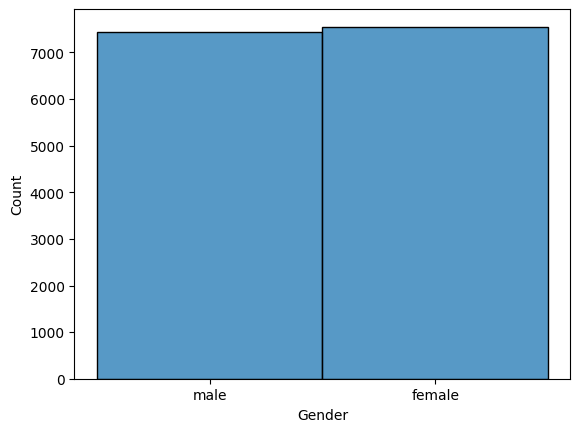

In [114]:
sns.histplot(data=df, x="Gender")

<Axes: >

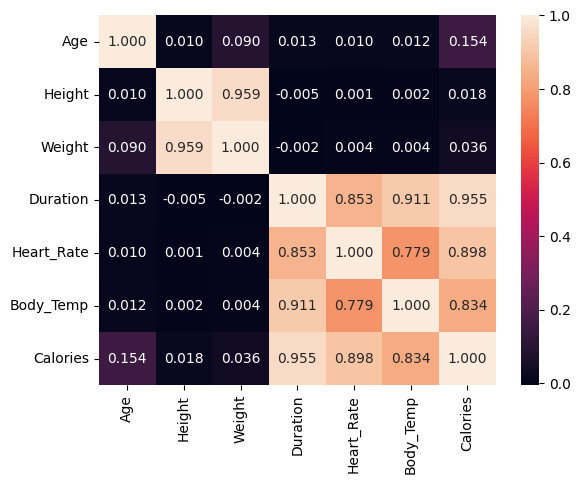

In [115]:
correlations = df.corr(numeric_only=True)

sns.heatmap(correlations, annot=True, fmt=".3f")

### Outlier Removal

In [116]:
mask = pd.Series(True, index=df.index)

for col in num_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask &= df[col].between(lower, upper)
df = df[mask]



In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      15000 non-null  object 
 1   Age         15000 non-null  int64  
 2   Height      15000 non-null  float64
 3   Weight      15000 non-null  float64
 4   Duration    15000 non-null  float64
 5   Heart_Rate  15000 non-null  float64
 6   Body_Temp   15000 non-null  float64
 7   Calories    15000 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 937.6+ KB


In [118]:
X = df.drop("Calories", axis=1)
y = df["Calories"]

In [119]:
num_columns = X.select_dtypes(include=["int64", "float64"]).columns
cat_columns = X.select_dtypes(include=["object"]).columns

In [120]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [121]:
preprocessor = ColumnTransformer(
    transformers=[
        ('gender', OneHotEncoder(drop='first', handle_unknown="ignore"), cat_columns),
        ('scaler', StandardScaler(), num_columns)
    ],
    remainder="passthrough")


In [122]:
models = {
    "LinearRegression":LinearRegression(),
    "DecisionTress":DecisionTreeRegressor(max_depth=10, random_state=42),
    "RandomForest":RandomForestRegressor(n_estimators=50,max_depth=10,random_state=42),
    "GradientBoosting":GradientBoostingRegressor(n_estimators=50,random_state=42),
    "XGBoost":XGBRegressor(random_state=42),
    "CatBoost": CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_seed=42, verbose=0)
}

In [123]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    # Cross-validation only on training data
    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="r2"
    )

    print(name)
    print("CV R²:", cv_scores)
    print("Mean CV R²:", cv_scores.mean())

LinearRegression
CV R²: [0.96617392 0.96587076 0.9678186  0.96773223 0.96685066]
Mean CV R²: 0.9668892331264054
DecisionTress
CV R²: [0.99083115 0.98951988 0.98980016 0.98996836 0.9901147 ]
Mean CV R²: 0.9900468490130242
RandomForest
CV R²: [0.99656494 0.99674399 0.99611964 0.99665858 0.99637279]
Mean CV R²: 0.996491987618706
GradientBoosting
CV R²: [0.99216678 0.99319603 0.99205212 0.99294945 0.99290015]
Mean CV R²: 0.9926529058173313
XGBoost
CV R²: [0.99872322 0.99874602 0.99859385 0.99854343 0.99868062]
Mean CV R²: 0.9986574268275537
CatBoost
CV R²: [0.99961578 0.99967197 0.99954345 0.99968812 0.99968177]
Mean CV R²: 0.9996402165935052


In [124]:
model_metrics = []

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    # Cross-validation only on training data
    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="r2"
    )
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Evaluation metrics
    mae = mean_absolute_error(y_test,y_pred)
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    test_r2 = r2_score(y_test,y_pred)

    print(name)
    print("CV R²:", cv_scores)

    model_metrics.append({
        "Model":name,
        "MAE":round(mae, 2),
        "RMSE":round(rmse, 2),
        "R2":round(test_r2, 4),
        "Mean CV R²":cv_scores.mean()
    })

model_metrics_df = pd.DataFrame(model_metrics)
model_metrics_df = model_metrics_df.sort_values(by="R2", ascending=False)
model_metrics_df

LinearRegression
CV R²: [0.96617392 0.96587076 0.9678186  0.96773223 0.96685066]
DecisionTress
CV R²: [0.99083115 0.98951988 0.98980016 0.98996836 0.9901147 ]
RandomForest
CV R²: [0.99656494 0.99674399 0.99611964 0.99665858 0.99637279]
GradientBoosting
CV R²: [0.99216678 0.99319603 0.99205212 0.99294945 0.99290015]
XGBoost
CV R²: [0.99872322 0.99874602 0.99859385 0.99854343 0.99868062]
CatBoost
CV R²: [0.99961578 0.99967197 0.99954345 0.99968812 0.99968177]


,Model,MAE,RMSE,R2,Mean CV R²
5,CatBoost,0.80,1.10,0.9997,0.999640
4,XGBoost,1.47,2.11,0.9989,0.998657
2,RandomForest,2.29,3.39,0.9971,0.996492
3,GradientBoosting,3.67,5.18,0.9933,0.992653
1,DecisionTress,3.96,5.81,0.9916,0.990047
0,LinearRegression,8.45,11.49,0.9673,0.966889
